In [85]:
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.mixture import GaussianMixture
from typing import Sequence, Dict, List
from scipy.stats import entropy
from collections import Counter
import joblib

In [73]:
ARTIFACTS_DIR = "artifacts"

def load_artifacts(artifacts_dir=ARTIFACTS_DIR):
    X = np.load("artifacts/embeddings.npy")
    doc_ids = np.load("artifacts/ids.npy")
    y = np.load("artifacts/label_indices.npy")            # ints
    y_names_doc = np.load("artifacts/label_names.npy")    # per-document strings
    texts_clean = np.load("artifacts/texts_clean.npy", allow_pickle=True)
    return X, doc_ids, y, y_names_doc, texts_clean

X, doc_ids, y, y_names_doc, texts_clean = load_artifacts()
X.shape, len(texts_clean), texts_clean[0][:200]

((11314, 384),
 11314,
 'i was wondering if anyone out there could enlighten me on this car i saw the other day. it was a 2-door sports car, looked to be from the late 60s/ early 70s. it was called a bricklin. the doors were ')

In [67]:
def scan_gmm_components(
    X: np.ndarray,
    n_components_list: Sequence[int],
    covariance_type: str = "full",
    random_state: int = 42,
    max_iter: int = 200,
) -> Dict[str, List[float]]:
    """
    Fit a GMM for each n_components; return BIC and AIC over X.
    """
    bic_scores = []
    aic_scores = []

    for n in n_components_list:
        print(f"Fitting GMM with n_components={n} ...")
        gmm = GaussianMixture(
            n_components=n,
            covariance_type=covariance_type,
            random_state=random_state,
            max_iter=max_iter,
            verbose=0,
        )
        gmm.fit(X)
        bic_scores.append(gmm.bic(X))
        aic_scores.append(gmm.aic(X))

    return {
        "n_components": list(n_components_list),
        "bic": bic_scores,
        "aic": aic_scores,
    }

In [68]:
n_components_list = list(range(5, 41))  # 5 to 40 inclusive

results = scan_gmm_components(
    X,
    n_components_list=n_components_list,
    covariance_type="diag",
    random_state=42,
    max_iter=300,
)

print("\n# n_components  BIC              AIC")
for n, bic, aic in zip(results["n_components"], results["bic"], results["aic"]):
    print(f"{n:2d}           {bic: .2f}    {aic: .2f}")

best_bic_idx = int(np.argmin(results["bic"]))
best_aic_idx = int(np.argmin(results["aic"]))

print("\nBest by BIC:")
print("  n_components =", results["n_components"][best_bic_idx],
      "BIC =", results["bic"][best_bic_idx])

print("Best by AIC:")
print("  n_components =", results["n_components"][best_aic_idx],
      "AIC =", results["aic"][best_aic_idx])

Fitting GMM with n_components=5 ...
Fitting GMM with n_components=6 ...
Fitting GMM with n_components=7 ...
Fitting GMM with n_components=8 ...
Fitting GMM with n_components=9 ...
Fitting GMM with n_components=10 ...
Fitting GMM with n_components=11 ...
Fitting GMM with n_components=12 ...
Fitting GMM with n_components=13 ...
Fitting GMM with n_components=14 ...
Fitting GMM with n_components=15 ...
Fitting GMM with n_components=16 ...
Fitting GMM with n_components=17 ...
Fitting GMM with n_components=18 ...
Fitting GMM with n_components=19 ...
Fitting GMM with n_components=20 ...
Fitting GMM with n_components=21 ...
Fitting GMM with n_components=22 ...
Fitting GMM with n_components=23 ...
Fitting GMM with n_components=24 ...
Fitting GMM with n_components=25 ...
Fitting GMM with n_components=26 ...
Fitting GMM with n_components=27 ...
Fitting GMM with n_components=28 ...
Fitting GMM with n_components=29 ...
Fitting GMM with n_components=30 ...
Fitting GMM with n_components=31 ...
Fittin

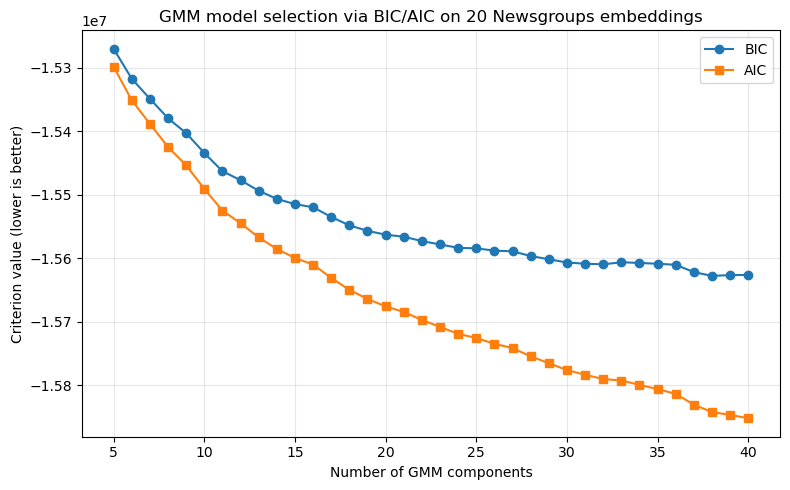

In [69]:
# results is the dict returned by scan_gmm_components(...)
# results["n_components"], results["bic"], results["aic"]

fig, ax = plt.subplots(figsize=(8, 5))  # create Figure and single Axes

ax.plot(results["n_components"], results["bic"],
        marker="o", label="BIC")
ax.plot(results["n_components"], results["aic"],
        marker="s", label="AIC")

ax.set_xlabel("Number of GMM components")
ax.set_ylabel("Criterion value (lower is better)")
ax.set_title("GMM model selection via BIC/AIC on 20 Newsgroups embeddings")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()

In [70]:
ARTIFACTS_DIR = "artifacts"

# 1. Hyperparameters for the final clustering model
n_components_final = 20          # chosen for interpretability (between 5 and 40)
covariance_type_final = "diag"   # diagonal covariances: lighter, more stable in 384-D
max_iter_final = 300             # allow EM to converge comfortably
random_state_final = 42          # reproducible initialization

# 2. Fit the final GMM on the full embedding space (not PCA)
gmm_final = GaussianMixture(
    n_components=n_components_final,
    covariance_type=covariance_type_final,
    max_iter=max_iter_final,
    random_state=random_state_final,
    verbose=1,                   # set 0 if you prefer silent
)

gmm_final.fit(X)                 # X: (11314, 384) embeddings

# 3. Compute soft and hard assignments
cluster_proba = gmm_final.predict_proba(X)
# cluster_proba[i, k] = P(cluster k | document i), sums to 1 over k

cluster_labels_hard = gmm_final.predict(X)
# hard labels only for analysis (e.g., cluster sizes and purity),
# NOT as the final output (assignment requires fuzzy memberships).

print("cluster_proba shape:", cluster_proba.shape)
print("cluster_labels_hard shape:", cluster_labels_hard.shape)

# 4. Persist results for later analysis / API usage
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

np.save(os.path.join(ARTIFACTS_DIR, "gmm_diag20_cluster_proba.npy"), cluster_proba)
np.save(os.path.join(ARTIFACTS_DIR, "gmm_diag20_cluster_labels_hard.npy"), cluster_labels_hard)

print("Saved GMM outputs to artifacts/:")
print("  gmm_diag20_cluster_proba.npy")
print("  gmm_diag20_cluster_labels_hard.npy")

Initialization 0
  Iteration 10
Initialization converged.
cluster_proba shape: (11314, 20)
cluster_labels_hard shape: (11314,)
Saved GMM outputs to artifacts/:
  gmm_diag20_cluster_proba.npy
  gmm_diag20_cluster_labels_hard.npy


In [86]:
os.makedirs(ARTIFACTS_DIR, exist_ok=True)
joblib.dump(gmm_final, os.path.join(ARTIFACTS_DIR, "gmm_diag20_model.pkl"))

['artifacts/gmm_diag20_model.pkl']

In [71]:
def compute_membership_entropy(cluster_proba: np.ndarray) -> np.ndarray:
    """
    Given cluster probabilities of shape (n_docs, K),
    return per-document entropy in bits.
    Higher entropy => more uncertain / boundary document.
    """
    ent = entropy(cluster_proba, axis=1, base=2)
    return ent

ent = compute_membership_entropy(cluster_proba)

In [74]:
'''we can decorate the top clusters with human‑readable names based on their dominant true labels.'''
def build_cluster_names(labels_hard, y, y_names_doc, n_components):
    """
    Build names like 'cluster_3_comp.graphics' using the dominant label name.
    """
    summaries = summarize_clusters(labels_hard, y, y_names_doc, n_components)
    names = []
    for s in summaries:
        if s["dominant_label_name"] is None:
            names.append(f"cluster_{s['cluster']}_empty")
        else:
            names.append(f"cluster_{s['cluster']}_{s['dominant_label_name']}")
    return names

cluster_names = build_cluster_names(
    cluster_labels_hard,
    y,
    y_names_doc,
    n_components_final,
)

In [75]:
'''Sorts documents by descending entropy so the most uncertain ones come first.
For each doc, shows:
document index and id,
true newsgroup label,
entropy value,
top‑3 clusters and their probabilities (to see which clusters are competing),
a short text preview you can read in the notebook.'''
def get_boundary_documents(
    ent: np.ndarray,
    cluster_proba: np.ndarray,
    texts_clean: np.ndarray,
    doc_ids: np.ndarray,
    y: np.ndarray,
    y_names_doc: np.ndarray,
    cluster_names: list,
    top_k: int = 10,
    top_clusters_to_show: int = 3,
):
    """
    Return metadata for the top_k highest-entropy (most uncertain) documents.
    """
    order = np.argsort(-ent)          # sort by entropy descending
    top_idx = order[:top_k]

    records = []
    for idx in top_idx:
        probs = cluster_proba[idx]
        top_clusters = np.argsort(-probs)[:top_clusters_to_show]
        records.append({
            "doc_index": int(idx),
            "doc_id": str(doc_ids[idx]),
            "true_label_idx": int(y[idx]),
            "true_label_name": str(y_names_doc[idx]),
            "entropy_bits": float(ent[idx]),
            "top_clusters": top_clusters.tolist(),
            "top_clusters_proba": probs[top_clusters].tolist(),
            "top_cluster_names": [cluster_names[c] for c in top_clusters],
            "text_preview": str(texts_clean[idx])[:300],
        })
    return records

In [76]:
boundary_docs = get_boundary_documents(
    ent,
    cluster_proba,
    texts_clean,
    doc_ids,
    y,
    y_names_doc,
    cluster_names,
    top_k=10,
)

for rec in boundary_docs:
    print("=" * 80)
    print(f"Doc idx: {rec['doc_index']}  id: {rec['doc_id']}")
    print(f"True label: {rec['true_label_idx']} ({rec['true_label_name']})")
    print(f"Entropy: {rec['entropy_bits']:.3f} bits")
    print("Top clusters:")
    for k_idx, name, p in zip(
        rec["top_clusters"],
        rec["top_cluster_names"],
        rec["top_clusters_proba"],
    ):
        print(f"  {name} (idx {k_idx}): {p:.3f}")
    print("\nText preview:")
    print(rec["text_preview"])
    print()

Doc idx: 9078  id: train_9078
True label: 13 (sci.med)
Entropy: 1.894 bits
Top clusters:
  cluster_1_sci.med (idx 1): 0.405
  cluster_15_sci.space (idx 15): 0.260
  cluster_14_sci.space (idx 14): 0.258

Text preview:
the magnets are huge!  good mri sets with big (>1.5 tesla) magnets cost millions of dollars.  then, the radiologist wants $400 for reading each scan. --  ---------------------------------------------------------------------------- gordon banks  n3jxp      | "skepticism is the chastity of the intelle

Doc idx: 1178  id: train_1178
True label: 2 (comp.os.ms-windows.misc)
Entropy: 1.547 bits
Top clusters:
  cluster_3_comp.windows.x (idx 3): 0.507
  cluster_17_sci.electronics (idx 17): 0.361
  cluster_13_comp.sys.ibm.pc.hardware (idx 13): 0.071

Text preview:
try this:  flip your mouse over, and open up the cover that holds the mouse ball in place.  remove the ball, and inside you should see (probably) 3 rollers.  if any of the rollers have a tiny layer of caked-on dirt, dust,

In [77]:
def summarize_clusters(labels_hard: np.ndarray,
                       y: np.ndarray,
                       y_names_doc: np.ndarray,
                       n_components: int):
    """
    One summary dict per cluster: size, dominant true label + purity.
    y_names_doc is per-document label name (same shape as y).
    """
    summaries = []

    for k in range(n_components):
        mask = labels_hard == k
        cluster_y = y[mask]
        size = int(mask.sum())

        if size == 0:
            summaries.append({
                "cluster": k,
                "size": 0,
                "dominant_label_idx": None,
                "dominant_label_name": None,
                "purity": 0.0,
            })
            continue

        counts = Counter(cluster_y)
        dominant_label_idx, dominant_count = counts.most_common(1)[0]
        purity = dominant_count / size

        # pick any doc in this cluster with that label to get its name
        first_idx = np.where((mask) & (y == dominant_label_idx))[0][0]
        dominant_label_name = y_names_doc[first_idx]

        summaries.append({
            "cluster": k,
            "size": size,
            "dominant_label_idx": int(dominant_label_idx),
            "dominant_label_name": str(dominant_label_name),
            "purity": float(purity),
        })

    return summaries

cluster_summaries = summarize_clusters(
    cluster_labels_hard,
    y,
    y_names_doc,
    n_components_final,
)

In [78]:
print(f"{'cluster':>7} {'size':>6} {'purity':>8}  dominant_label")
for s in cluster_summaries:
    print(f"{s['cluster']:7d} {s['size']:6d} {s['purity']:8.3f}  {s['dominant_label_name']}")

cluster   size   purity  dominant_label
      0    529    0.582  rec.autos
      1    510    0.861  sci.med
      2    300    0.107  rec.autos
      3    418    0.926  comp.windows.x
      4    480    0.950  rec.sport.baseball
      5    713    0.330  comp.sys.ibm.pc.hardware
      6    652    0.609  soc.religion.christian
      7    363    0.964  sci.crypt
      8    778    0.380  comp.graphics
      9    431    0.905  talk.politics.mideast
     10    554    0.666  talk.politics.guns
     11    381    0.444  alt.atheism
     12    368    0.698  rec.motorcycles
     13    546    0.392  comp.sys.ibm.pc.hardware
     14    431    0.464  sci.space
     15   1181    0.216  sci.space
     16    491    0.963  rec.sport.hockey
     17    722    0.506  sci.electronics
     18    954    0.213  talk.politics.misc
     19    512    0.670  misc.forsale


In [79]:
def show_cluster_examples(
    cluster_id: int,
    cluster_labels_hard: np.ndarray,
    cluster_proba: np.ndarray,
    texts_clean: np.ndarray,
    doc_ids: np.ndarray,
    y: np.ndarray,
    y_names: np.ndarray,
    num_docs: int = 5,
):
    """
    Print a few example documents from a given cluster.
    Shows high-confidence 'core' docs first, then more ambiguous ones.
    """
    mask = cluster_labels_hard == cluster_id
    idxs = np.where(mask)[0]
    if len(idxs) == 0:
        print(f"Cluster {cluster_id} is empty.")
        return

    # Probability of this cluster for each doc
    probs_k = cluster_proba[idxs, cluster_id]

    # Sort indices by prob descending (core docs first)
    order = np.argsort(-probs_k)
    idxs_sorted = idxs[order]

    print(f"=== Cluster {cluster_id} examples (top {num_docs} by membership prob) ===")
    for i in idxs_sorted[:num_docs]:
        print("-" * 80)
        print(f"Doc idx: {i}  id: {doc_ids[i]}")
        print(f"True label: {y[i]} ({y_names[y[i]]})")
        print(f"P(cluster {cluster_id}) = {cluster_proba[i, cluster_id]:.3f}")
        print("Text preview:")
        print(str(texts_clean[i])[:400])
        print()


In [84]:
# Example: inspect cluster 0
show_cluster_examples(
    cluster_id=11,
    cluster_labels_hard=cluster_labels_hard,
    cluster_proba=cluster_proba,
    texts_clean=texts_clean,
    doc_ids=doc_ids,
    y=y,
    y_names=y_names,
    num_docs=5,
)

=== Cluster 11 examples (top 5 by membership prob) ===
--------------------------------------------------------------------------------
Doc idx: 28  id: train_28
True label: 15 (alt.atheism)
P(cluster 11) = 1.000
Text preview:
yes. (i am adamantly an environmentalist.  i will not use styrofoam table service. please keep that in mind as you read this post - i do not wish to attack environmentalism) a half truth is at least as dangerous as a complete lie.  a complete lie will rarely be readily accepted, while a half truth (the lie subtly hidden) is more powerfully offered by one who masquerades as an angel of light. satan

--------------------------------------------------------------------------------
Doc idx: 7552  id: train_7552
True label: 0 (rec.autos)
P(cluster 11) = 1.000
Text preview:
frank@d012s658.uucp (frank o'dwyer) writes ... while i'll agree that these are generally held to be "good things", i question whether they come very close to being objective values. especially consi

In [82]:
# Quick sanity check of label mapping
unique_labels = sorted(set(y))
for idx in unique_labels:
    print(idx, y_names[idx])

0 rec.autos
1 comp.sys.mac.hardware
2 comp.sys.mac.hardware
3 comp.graphics
4 sci.space
5 talk.politics.guns
6 sci.med
7 comp.sys.ibm.pc.hardware
8 comp.os.ms-windows.misc
9 comp.sys.mac.hardware
10 rec.motorcycles
11 talk.religion.misc
12 comp.sys.mac.hardware
13 sci.space
14 misc.forsale
15 alt.atheism
16 comp.graphics
17 rec.autos
18 sci.electronics
19 comp.windows.x
